**Student:** Aimen A Ali Etorki

**Student Number: 30095294**

**Year:** Feb 2025 Intake

**Supervisor:** Dr Mabrouka Abuhmida

**MSc Project:** CS4T702_2025/26 Artificial Intelligence 

**Project Title:**  Explainable Hybrid AI Model for Early Detection of Alzheimer’s Disease Using MRI-Derived Hippocampal and Brain Structural Features

# Notebook 4: Dataset Creation

## Objective

Apply the validated preprocessing pipeline across the full cohort and construct
the training, validation and test datasets using a stratified participant-level
split.

## Dataset Construction Approach

The dataset is constructed with particular attention to participant independence,
class representation and data traceability.

**1. Participant-level splitting.** Participants are assigned to only one of the
training, validation or test sets. All slices belonging to the same participant
therefore remain within a single split, preventing participant-level data leakage.

**2. Stratified splitting.** Diagnostic group labels are used during splitting to
maintain representation of CN, MCI and AD participants across the training,
validation and test sets.

**3. Class-coverage validation.** Each split is checked to confirm that all three
diagnostic groups are represented before the dataset is saved for modelling.

**4. Data provenance.** A manifest records the participant, diagnostic group,
dataset split and source slice information associated with the generated images,
allowing processed data to be traced back to their source.

**5. Shared preprocessing.** MRI preprocessing is performed using the functions
defined in `src/mri_utils.py`, ensuring that the same preprocessing configuration
validated in Notebook 3 is applied consistently across the full cohort.

> **Prerequisites:** run Notebook 1 to generate `participant_manifest.csv` and
> Notebook 2 to generate `src/mri_utils.py` before running this notebook.

In [1]:
# ============================================================
# Project Configuration
#
# The project root is identified automatically so that file paths
# remain relative to the project structure rather than depending
# on a specific computer or user directory.
# ============================================================

from pathlib import Path


def find_project_root(marker_folders=("MRI 1.5T & 3T Dataset", "notebooks")):
    """Walk upwards until a folder containing the project markers is found."""

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if any((candidate / m).exists() for m in marker_folders):
            return candidate

    # If the project root cannot be found, return a default path
    return Path(r"C:\Users\aimen\Documents\GitHub\MSc-Final-Project")


PROJECT_ROOT = find_project_root()

RAW_DATA = PROJECT_ROOT / "MRI 1.5T & 3T Dataset"
MRI_FOLDER = RAW_DATA / "ADNI"

CSV_FILE = PROJECT_ROOT / "MRI_1.5T___3T_Dataset_7_08_2026.csv"

PROCESSED_DATA = PROJECT_ROOT / "processed"
DATASET_FOLDER = PROJECT_ROOT / "dataset"
FINAL_DATASET_FOLDER = PROJECT_ROOT / "final_dataset"
MODELS_FOLDER = PROJECT_ROOT / "models"
RESULTS_FOLDER = PROJECT_ROOT / "results"
SRC_FOLDER = PROJECT_ROOT / "src"

for folder in [PROCESSED_DATA, DATASET_FOLDER, FINAL_DATASET_FOLDER,
               MODELS_FOLDER, RESULTS_FOLDER, SRC_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["CN", "MCI", "AD"]
RANDOM_SEED = 42

print("PROJECT_ROOT :", PROJECT_ROOT)
print()
print("Path check")
print("-" * 46)
for label, path in [
    ("MRI folder    ", MRI_FOLDER),
    ("Metadata CSV  ", CSV_FILE),
    ("Processed     ", PROCESSED_DATA),
    ("Final dataset ", FINAL_DATASET_FOLDER),
    ("Source module ", SRC_FOLDER),
]:
    status = "OK " if path.exists() else "MISSING"
    print(f"{label}: [{status}] {path}")

PROJECT_ROOT : C:\Users\aimen\Documents\GitHub\MSc-Final-Project

Path check
----------------------------------------------
MRI folder    : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI 1.5T & 3T Dataset\ADNI
Metadata CSV  : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\MRI_1.5T___3T_Dataset_7_08_2026.csv
Processed     : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\processed
Final dataset : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\final_dataset
Source module : [OK ] C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src


In [2]:
# ============================================================
# Libraries and Shared Pipeline Module
# ============================================================

import sys
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

if str(SRC_FOLDER) not in sys.path:
    sys.path.insert(0, str(SRC_FOLDER))

try:
    import mri_utils
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        f"src/mri_utils.py not found. Run Notebook 2 first."
    )

import importlib
importlib.reload(mri_utils)

print("mri_utils loaded from:", mri_utils.__file__)

mri_utils loaded from: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\src\mri_utils.py


In [5]:
# ============================================================
# Dataset Configuration
#
# Every parameter that shapes the dataset is declared here so
# that the saved dataset can be reproduced consistently.
# ============================================================

N_SLICES = 20            # slices sampled per participant
SKULL_STRIP = False      # evaluated but unreliable on this cohort
PLANE = "coronal"        # selected for visualising medial temporal structures
IMAGE_SIZE = (224, 224)

TEST_FRACTION = 0.15
VALIDATION_FRACTION = 0.15

# Dataset tag derived from the main preprocessing settings
DATASET_VERSION = (
    f"{PLANE}_n{N_SLICES}_"
    f"{'strip' if SKULL_STRIP else 'nostrip'}"
)

OUTPUT_FOLDER = FINAL_DATASET_FOLDER

print("Dataset configuration")
print("-" * 46)
print(f"  Slices per participant : {N_SLICES}")
print(f"  Skull stripping        : {SKULL_STRIP}")
print(f"  Slicing plane          : {PLANE}")
print(f"  Image size             : {IMAGE_SIZE}")
print(f"  Train / Val / Test     : "
      f"{1 - TEST_FRACTION - VALIDATION_FRACTION:.0%} / "
      f"{VALIDATION_FRACTION:.0%} / {TEST_FRACTION:.0%}")
print(f"  Random seed            : {RANDOM_SEED}")
print(f"  Dataset tag            : {DATASET_VERSION}")
print(f"  Output folder          : {OUTPUT_FOLDER}")

Dataset configuration
----------------------------------------------
  Slices per participant : 20
  Skull stripping        : False
  Slicing plane          : coronal
  Image size             : (224, 224)
  Train / Val / Test     : 70% / 15% / 15%
  Random seed            : 42
  Dataset tag            : coronal_n20_nostrip
  Output folder          : C:\Users\aimen\Documents\GitHub\MSc-Final-Project\final_dataset


## 4.1 Load the Participant Manifest

The cohort is loaded from the participant manifest produced by Notebook 1, where
participant labels and MRI availability have already been verified. Using this
manifest ensures that the same validated cohort is carried consistently into
dataset creation.

In [7]:
# ============================================================
# Load and Validate the Manifest
# ============================================================

MANIFEST_PATH = PROJECT_ROOT / "participant_manifest.csv"

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"{MANIFEST_PATH} not found. Run Notebook 1 first."
    )

manifest = pd.read_csv(MANIFEST_PATH)

print(f"Participants in manifest : {len(manifest)}")

# ---- integrity checks ----
assert manifest["Subject"].is_unique, "Duplicate participants in manifest"

unexpected = set(manifest["Group"]) - set(CLASS_NAMES)
assert not unexpected, f"Unexpected diagnostic labels: {unexpected}"

print()
print("Class distribution:")
distribution = manifest["Group"].value_counts().reindex(CLASS_NAMES)
for group in CLASS_NAMES:
    count = distribution[group]
    print(f"  {group:<4}: {count:>4}  ({count / len(manifest):.1%})")

smallest_group = distribution.idxmin()
smallest_count = distribution.min()

print(f"\nSmallest group: {smallest_group} with {smallest_count} participants")

expected_test = int(smallest_count * TEST_FRACTION)

print(f"At a {TEST_FRACTION:.0%} test fraction this yields roughly "
      f"{expected_test} {smallest_group} participants in the test set.")

if expected_test < 3:
    print()
    print("WARNING: fewer than 3 participants of the smallest class will")
    print("reach the test set. Per-class metrics for that group will be")
    print("extremely unstable and should be interpreted with caution.")

display(manifest.head())

Participants in manifest : 411

Class distribution:
  CN  :  117  (28.5%)
  MCI :  201  (48.9%)
  AD  :   93  (22.6%)

Smallest group: AD with 93 participants
At a 15% test fraction this yields roughly 13 AD participants in the test set.


,Subject,Group,Age,Sex,Visit,Acq Date,MRI_Available
0,011_S_0002,CN,74,M,sc,2005-08-26,True
1,011_S_0003,AD,81,M,sc,2005-09-01,True
2,011_S_0005,CN,74,M,sc,2005-09-02,True
3,022_S_0007,AD,75,M,sc,2005-09-13,True
4,011_S_0008,CN,85,F,sc,2005-09-13,True


## 4.2 Process the Cohort

Each participant is processed using `mri_utils.preprocess_participant()`, the same
preprocessing function validated in Notebook 3. Any processing failures are recorded
while the remaining participants continue to be processed, preventing a single
unreadable scan from interrupting the full cohort workflow.

In [8]:
# ============================================================
# Apply the Pipeline to Every Participant
# ============================================================

images = []
labels = []
participant_ids = []
slice_indices = []

processing_records = []
failures = []

start_time = time.time()

total = len(manifest)

for number, row in enumerate(manifest.itertuples(), start=1):

    subject = row.Subject
    diagnosis = row.Group

    try:

        participant_slices, metadata = mri_utils.preprocess_participant(
            MRI_FOLDER / subject,
            n_slices=N_SLICES,
            skull_strip=SKULL_STRIP,
            image_size=IMAGE_SIZE,
            plane=PLANE,
        )

        for position, image in enumerate(participant_slices):
            images.append(image)
            labels.append(diagnosis)
            participant_ids.append(subject)
            slice_indices.append(metadata["selected_indices"][position])

        processing_records.append({
            "Subject": subject,
            "Group": diagnosis,
            "Slices": len(participant_slices),
            "OriginalSlices": metadata["n_slices"],
            "BrainFraction": metadata["brain_fraction"],
            "Manufacturer": metadata["manufacturer"],
            "Sequence": metadata["sequence"],
        })

        status = "ok"

    except Exception as error:
        failures.append({
            "Subject": subject,
            "Group": diagnosis,
            "Error": str(error)[:120],
        })
        status = f"FAILED - {str(error)[:60]}"

    if number % 10 == 0 or number == total or status != "ok":
        elapsed = time.time() - start_time
        rate = number / elapsed if elapsed > 0 else 0
        remaining = (total - number) / rate if rate > 0 else 0
        print(f"  [{number:>3}/{total}] {subject:<14} {status:<12} "
              f"| {elapsed / 60:.1f} min elapsed, "
              f"~{remaining / 60:.1f} min remaining")

elapsed_total = time.time() - start_time

print()
print("=" * 58)
print(f"Processing complete in {elapsed_total / 60:.1f} minutes")
print("=" * 58)
print(f"  Successful : {len(processing_records)}")
print(f"  Failed     : {len(failures)}")
print(f"  Images     : {len(images):,}")

if failures:
    print("\nFailures:")
    display(pd.DataFrame(failures))

c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.07004347169841959184'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.01636491517057020153'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


  [ 10/411] 023_S_0030     ok           | 0.8 min elapsed, ~30.5 min remaining


c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.04074793767569246320'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.03005105354784130366'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.03003024075569899106'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_l

  [ 20/411] 022_S_0044     ok           | 1.5 min elapsed, ~30.0 min remaining


c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.02260824608422558808'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.03906126167454097012'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.03027250585714135659'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_l

...

  [390/411] 072_S_1211     ok           | 34.8 min elapsed, ~1.9 min remaining


c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.01801701750270899952'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.05413357331612218002'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.06246376702703648012'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_l

  [400/411] 041_S_1391     ok           | 35.7 min elapsed, ~1.0 min remaining


c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.02301776147986493755'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.02304895020987910095'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
c:\Users\aimen\Desktop\MSc AI 2026_2027\vsc001\adni_03\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.07611490480053252453'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_l

  [410/411] 041_S_1435     ok           | 36.6 min elapsed, ~0.1 min remaining
  [411/411] 041_S_1420     ok           | 36.7 min elapsed, ~0.0 min remaining

Processing complete in 36.7 minutes
  Successful : 411
  Failed     : 0
  Images     : 8,220


In [9]:
# ============================================================
# Convert to Arrays and Validate
# ============================================================

images = np.array(images, dtype=np.float32)
labels = np.array(labels)
participant_ids = np.array(participant_ids)
slice_indices = np.array(slice_indices)

print(f"Images          : {images.shape}  ({images.nbytes / 1e9:.2f} GB)")
print(f"Labels          : {labels.shape}")
print(f"Participant IDs : {participant_ids.shape}")

assert len(images) == len(labels) == len(participant_ids) == len(slice_indices), \
    "Array lengths do not match"

assert images.min() >= 0.0 and images.max() <= 1.0, \
    f"Intensities outside [0,1]: {images.min()} to {images.max()}"

assert not np.isnan(images).any(), "NaN values present in images"

print("\nAll integrity checks passed.")

# ------------------------------------------------------------
# Slices per participant
# ------------------------------------------------------------

records = pd.DataFrame(processing_records)

print(f"\nSlices per participant: "
      f"{records['Slices'].min()}-{records['Slices'].max()} "
      f"(mean {records['Slices'].mean():.1f})")

print(f"Effective sample size is {records['Subject'].nunique()} "
      f"participants, not {len(images):,} images.")

# ------------------------------------------------------------
# Brain extraction quality across the cohort
# ------------------------------------------------------------

if SKULL_STRIP and records["BrainFraction"].notna().any():

    print(f"\nBrain mask coverage: "
          f"{records['BrainFraction'].min():.1%} to "
          f"{records['BrainFraction'].max():.1%} "
          f"(median {records['BrainFraction'].median():.1%})")

    suspicious = records[
        (records["BrainFraction"] < 0.05) | (records["BrainFraction"] > 0.50)
    ]

    if len(suspicious) > 0:
        print(f"\n{len(suspicious)} participants have unusual mask coverage.")
        print("Inspect these before trusting their images:")
        display(suspicious[["Subject", "Group", "BrainFraction"]])
    else:
        print("No participant shows anomalous mask coverage.")

Images          : (8220, 224, 224)  (1.65 GB)
Labels          : (8220,)
Participant IDs : (8220,)

All integrity checks passed.

Slices per participant: 20-20 (mean 20.0)
Effective sample size is 411 participants, not 8,220 images.


,Participants,Images,Images per participant
CN,117,2340,20.0
MCI,201,4020,20.0
AD,93,1860,20.0


Majority-class baseline (participants): 0.4891


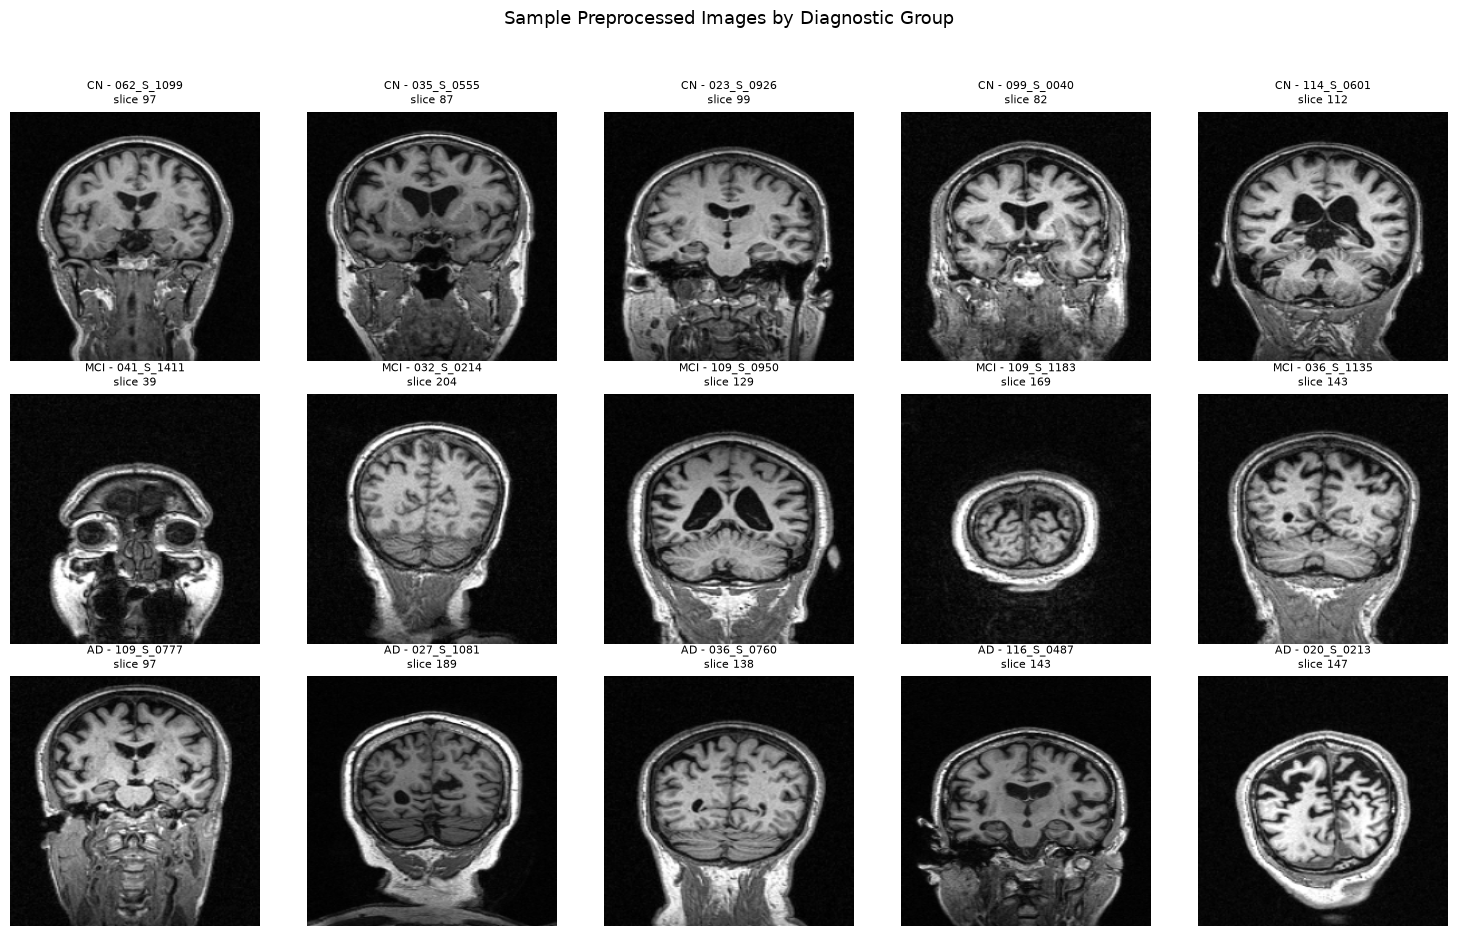

In [10]:
# ============================================================
# Class Distribution
# ============================================================

image_distribution = pd.Series(labels).value_counts().reindex(CLASS_NAMES)
participant_distribution = records["Group"].value_counts().reindex(CLASS_NAMES)

summary = pd.DataFrame({
    "Participants": participant_distribution,
    "Images": image_distribution,
})

summary["Images per participant"] = (
    summary["Images"] / summary["Participants"]
).round(1)

display(summary)

majority_baseline = participant_distribution.max() / participant_distribution.sum()
print(f"Majority-class baseline (participants): {majority_baseline:.4f}")

# ------------------------------------------------------------
# Sample images
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 5, figsize=(15, 9.5))

rng = np.random.default_rng(RANDOM_SEED)

for row_index, group in enumerate(CLASS_NAMES):

    group_positions = np.where(labels == group)[0]
    chosen = rng.choice(group_positions, size=5, replace=False)

    for column_index, position in enumerate(chosen):
        axes[row_index, column_index].imshow(
            images[position], cmap="gray", vmin=0, vmax=1)
        axes[row_index, column_index].set_title(
            f"{group} - {participant_ids[position]}\n"
            f"slice {slice_indices[position]}", fontsize=8)
        axes[row_index, column_index].axis("off")

plt.suptitle("Sample Preprocessed Images by Diagnostic Group", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4.3 Stratified Participant-Level Split

Two requirements are enforced when dividing the dataset into training, validation
and test sets:

**Participant-level separation.** All images belonging to the same participant are
assigned to a single subset. This prevents participant-level data leakage, where
highly similar slices from the same MRI could otherwise appear in both training
and evaluation data.

**Class stratification.** The split preserves representation of CN, MCI and AD
participants across the training, validation and test sets. This helps maintain
comparable diagnostic-group proportions and ensures that each class is represented
during model evaluation.

Both requirements are enforced during dataset splitting and verified before the
final arrays are created.

In [11]:
# ============================================================
# Stratified Split at Participant Level
# ============================================================

participant_table = (
    records[["Subject", "Group"]]
    .drop_duplicates()
    .sort_values("Subject")
    .reset_index(drop=True)
)

print(f"Splitting {len(participant_table)} participants")
print("Stratifying on diagnostic group\n")

# ---- first split: train vs (validation + test) ----
train_table, holdout_table = train_test_split(
    participant_table,
    test_size=TEST_FRACTION + VALIDATION_FRACTION,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=participant_table["Group"],
)

# ---- second split: validation vs test ----
relative_test = TEST_FRACTION / (TEST_FRACTION + VALIDATION_FRACTION)

validation_table, test_table = train_test_split(
    holdout_table,
    test_size=relative_test,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=holdout_table["Group"],
)

train_participants = set(train_table["Subject"])
validation_participants = set(validation_table["Subject"])
test_participants = set(test_table["Subject"])

print(f"Train      : {len(train_participants):>3} participants")
print(f"Validation : {len(validation_participants):>3} participants")
print(f"Test       : {len(test_participants):>3} participants")

Splitting 411 participants
Stratifying on diagnostic group

Train      : 287 participants
Validation :  62 participants
Test       :  62 participants


In [13]:
# ============================================================
# Verify the Participant-Level Split
#
# Check participant separation, complete assignment, class
# coverage and diagnostic-group proportions across all subsets.
# ============================================================

# ---- 1. no participant appears in more than one subset ----
assert train_participants.isdisjoint(validation_participants)
assert train_participants.isdisjoint(test_participants)
assert validation_participants.isdisjoint(test_participants)

print("1. No participant overlap between subsets.")

# ---- 2. every participant is assigned somewhere ----
assigned = train_participants | validation_participants | test_participants
expected = set(participant_table["Subject"])

assert assigned == expected, \
    f"{len(expected - assigned)} participants unassigned"

print("2. Every participant assigned to exactly one subset.")

# ---- 3. every class present in every subset ----
split_distribution = pd.DataFrame({
    "Train": train_table["Group"].value_counts(),
    "Validation": validation_table["Group"].value_counts(),
    "Test": test_table["Group"].value_counts(),
}).reindex(CLASS_NAMES).fillna(0).astype(int)

display(split_distribution)

missing_classes = []

for split_name in ["Train", "Validation", "Test"]:
    absent = split_distribution.index[split_distribution[split_name] == 0]
    for class_name in absent:
        missing_classes.append(f"{class_name} missing from {split_name}")

if missing_classes:
    raise ValueError(
        "Split failed - a diagnostic class is absent from a subset:\n  "
        + "\n  ".join(missing_classes)
        + "\n\nConsider adjusting the split fractions or using "
          "cross-validation if the available class size is too small."
    )

print("3. All three classes present in all three subsets.")

# ---- 4. proportions preserved ----
proportions = (
    split_distribution / split_distribution.sum(axis=0) * 100
).round(1)

print("\nClass proportions per subset (%)")
display(proportions)

overall = (
    participant_table["Group"].value_counts(normalize=True)
    .reindex(CLASS_NAMES) * 100
).round(1)

print("Overall cohort proportions (%)")
display(overall.to_frame("Percent"))

max_deviation = (proportions.sub(overall, axis=0)).abs().max().max()

print(f"Largest deviation from cohort proportions: {max_deviation:.1f} "
      f"percentage points")

if max_deviation > 15:
    print("\nNote: deviation is large because the subsets are small. "
          "Stratification cannot do better with this few participants.")

# ---- 5. warn where a class is thinly represented ----
print()
for split_name in ["Validation", "Test"]:
    for class_name in CLASS_NAMES:
        count = split_distribution.loc[class_name, split_name]
        if count < 3:
            print(f"CAUTION: only {count} {class_name} participant(s) in "
                  f"{split_name}. Per-class metrics will be unstable.")

1. No participant overlap between subsets.
2. Every participant assigned to exactly one subset.


,Train,Validation,Test
Group,,,
CN,82,17,18
MCI,140,31,30
AD,65,14,14


3. All three classes present in all three subsets.

Class proportions per subset (%)


,Train,Validation,Test
Group,,,
CN,28.6,27.4,29.0
MCI,48.8,50.0,48.4
AD,22.6,22.6,22.6


Overall cohort proportions (%)


,Percent
Group,
CN,28.5
MCI,48.9
AD,22.6


Largest deviation from cohort proportions: 1.1 percentage points



In [14]:
# ============================================================
# Build the Final Arrays
# ============================================================

train_mask = np.isin(participant_ids, list(train_participants))
validation_mask = np.isin(participant_ids, list(validation_participants))
test_mask = np.isin(participant_ids, list(test_participants))

X_train, y_train, train_ids = (
    images[train_mask], labels[train_mask], participant_ids[train_mask])

X_validation, y_validation, validation_ids = (
    images[validation_mask], labels[validation_mask],
    participant_ids[validation_mask])

X_test, y_test, test_ids = (
    images[test_mask], labels[test_mask], participant_ids[test_mask])

split_summary = pd.DataFrame({
    "Participants": [
        len(train_participants),
        len(validation_participants),
        len(test_participants),
    ],
    "Images": [len(X_train), len(X_validation), len(X_test)],
}, index=["Train", "Validation", "Test"])

split_summary["Image %"] = (
    split_summary["Images"] / split_summary["Images"].sum() * 100
).round(1)

display(split_summary)

assert len(X_train) + len(X_validation) + len(X_test) == len(images), \
    "Images lost during splitting"

print("All images accounted for.")

# ------------------------------------------------------------
# Per-split majority-class baselines
# ------------------------------------------------------------

print("\nMajority-class baseline per subset (image level):")
for name, subset_labels in [
    ("Train", y_train), ("Validation", y_validation), ("Test", y_test)
]:
    counts = pd.Series(subset_labels).value_counts()
    print(f"  {name:<11}: {counts.max() / counts.sum():.4f} "
          f"(predicting {counts.idxmax()} for everything)")

,Participants,Images,Image %
Train,287,5740,69.8
Validation,62,1240,15.1
Test,62,1240,15.1


All images accounted for.

Majority-class baseline per subset (image level):
  Train      : 0.4878 (predicting MCI for everything)
  Validation : 0.5000 (predicting MCI for everything)
  Test       : 0.4839 (predicting MCI for everything)


## 4.4 Save the Dataset

The final arrays are saved for use in Notebook 5. A provenance manifest and dataset
configuration record are saved alongside them, allowing each processed image to be
traced to its participant, diagnostic group, dataset split and preprocessing
parameters.

In [15]:
# ============================================================
# Save Arrays
# ============================================================

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

arrays = {
    "X_train": X_train, "X_validation": X_validation, "X_test": X_test,
    "y_train": y_train, "y_validation": y_validation, "y_test": y_test,
    "train_ids": train_ids, "validation_ids": validation_ids,
    "test_ids": test_ids,
}

for name, array in arrays.items():
    np.save(OUTPUT_FOLDER / f"{name}.npy", array)

print(f"Saved to {OUTPUT_FOLDER}\n")

total_size = 0
for name in arrays:
    path = OUTPUT_FOLDER / f"{name}.npy"
    size_mb = path.stat().st_size / 1e6
    total_size += size_mb
    print(f"  {name:<18} {str(arrays[name].shape):<22} {size_mb:>9.1f} MB")

print(f"\n  {'TOTAL':<18} {'':<22} {total_size:>9.1f} MB")

Saved to C:\Users\aimen\Documents\GitHub\MSc-Final-Project\final_dataset

  X_train            (5740, 224, 224)          1152.0 MB
  X_validation       (1240, 224, 224)           248.9 MB
  X_test             (1240, 224, 224)           248.9 MB
  y_train            (5740,)                      0.1 MB
  y_validation       (1240,)                      0.0 MB
  y_test             (1240,)                      0.0 MB
  train_ids          (5740,)                      0.2 MB
  validation_ids     (1240,)                      0.0 MB
  test_ids           (1240,)                      0.0 MB

  TOTAL                                        1650.2 MB


In [18]:
# ============================================================
# Save Provenance Manifest and Configuration
# ============================================================

# ---- image-level provenance ----
split_lookup = {}
for subject in train_participants:
    split_lookup[subject] = "Train"
for subject in validation_participants:
    split_lookup[subject] = "Validation"
for subject in test_participants:
    split_lookup[subject] = "Test"

provenance = pd.DataFrame({
    "Subject": participant_ids,
    "Group": labels,
    "SliceIndex": slice_indices,
    "Split": [split_lookup[s] for s in participant_ids],
})

provenance.to_csv(OUTPUT_FOLDER / "image_manifest.csv", index=False)

# ---- participant-level record ----
records["Split"] = records["Subject"].map(split_lookup)
records.to_csv(OUTPUT_FOLDER / "participant_records.csv", index=False)

# ---- configuration ----
configuration = {
    "dataset_version": DATASET_VERSION,
    "created": pd.Timestamp.now().isoformat(timespec="seconds"),
    "n_participants": int(len(participant_table)),
    "n_images": int(len(images)),
    "n_slices_per_participant": N_SLICES,
    "skull_stripped": SKULL_STRIP,
    "plane": PLANE,
    "image_size": list(IMAGE_SIZE),
    "lower_percentile": mri_utils.LOWER_PERCENTILE,
    "upper_percentile": mri_utils.UPPER_PERCENTILE,
    "signal_threshold": mri_utils.SIGNAL_THRESHOLD,
    "brain_content_threshold": mri_utils.BRAIN_CONTENT_THRESHOLD,
    "random_seed": RANDOM_SEED,
    "train_fraction": 1 - TEST_FRACTION - VALIDATION_FRACTION,
    "validation_fraction": VALIDATION_FRACTION,
    "test_fraction": TEST_FRACTION,
    "stratified": True,
    "split_participants": {
        "train": int(len(train_participants)),
        "validation": int(len(validation_participants)),
        "test": int(len(test_participants)),
    },
    "split_class_counts": split_distribution.to_dict(),
    "majority_baseline_participants": round(float(majority_baseline), 4),
    "failed_participants": [f["Subject"] for f in failures],
}

with open(OUTPUT_FOLDER / "dataset_config.json", "w") as handle:
    json.dump(configuration, handle, indent=2)

print("Saved:")
print("  image_manifest.csv       - every image traced to participant/split")
print("  participant_records.csv  - per-participant processing record")
print("  dataset_config.json      - full parameter record")

print()
print(json.dumps(configuration, indent=2))

Saved:
  image_manifest.csv       - every image traced to participant/split
  participant_records.csv  - per-participant processing record
  dataset_config.json      - full parameter record

{
  "dataset_version": "coronal_n20_nostrip",
  "created": "2026-08-27T17:33:33",
  "n_participants": 411,
  "n_images": 8220,
  "n_slices_per_participant": 20,
  "skull_stripped": false,
  "plane": "coronal",
  "image_size": [
    224,
    224
  ],
  "lower_percentile": 1,
  "upper_percentile": 99,
  "signal_threshold": 0.05,
  "brain_content_threshold": 0.7,
  "random_seed": 42,
  "train_fraction": 0.7,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "stratified": true,
  "split_participants": {
    "train": 287,
    "validation": 62,
    "test": 62
  },
  "split_class_counts": {
    "Train": {
      "CN": 82,
      "MCI": 140,
      "AD": 65
    },
    "Validation": {
      "CN": 17,
      "MCI": 31,
      "AD": 14
    },
    "Test": {
      "CN": 18,
      "MCI": 30,
      "AD": 14
  

In [19]:
# ============================================================
# Final Verification
#
# Reload the saved arrays and verify their integrity before
# they are used for model development in Notebook 5.
# ============================================================

print("Reloading saved arrays...\n")

reloaded = {
    name: np.load(OUTPUT_FOLDER / f"{name}.npy", allow_pickle=True)
    for name in arrays
}

for name in arrays:
    assert reloaded[name].shape == arrays[name].shape, \
        f"{name} shape changed on reload"

print("Shapes preserved on reload.")

# ---- participant separation still holds after the round trip ----
reloaded_train = set(reloaded["train_ids"])
reloaded_validation = set(reloaded["validation_ids"])
reloaded_test = set(reloaded["test_ids"])

assert reloaded_train.isdisjoint(reloaded_validation)
assert reloaded_train.isdisjoint(reloaded_test)
assert reloaded_validation.isdisjoint(reloaded_test)

print("Participant separation verified on the reloaded data.")

# ---- all classes present in each reloaded subset ----
for name, subset_labels in [
    ("train", reloaded["y_train"]),
    ("validation", reloaded["y_validation"]),
    ("test", reloaded["y_test"]),
]:
    present = set(np.unique(subset_labels))
    missing = set(CLASS_NAMES) - present
    assert not missing, f"{name} is missing {missing} after reload"

print("All three classes present in every reloaded subset.")

print()
print("Dataset is ready for Notebook 5.")

Reloading saved arrays...

Shapes preserved on reload.
Participant separation verified on the reloaded data.
All three classes present in every reloaded subset.

Dataset is ready for Notebook 5.


In [20]:
# ============================================================
# Notebook 4 Summary
# ============================================================

print("=" * 60)
print("               DATASET CREATION SUMMARY")
print("=" * 60)

print(f"Slicing plane      : {PLANE}")
print(f"Dataset version    : {DATASET_VERSION}")
print(f"Participants       : {len(participant_table)}")
print(f"Images             : {len(images):,}")
print(f"Slices/participant : {N_SLICES}")
print(f"Skull stripped     : {SKULL_STRIP}")
print(f"Image size         : {IMAGE_SIZE}")

print()
print("Split (participants / images)")
print("-" * 48)

for name, participants, image_count in [
    ("Train", len(train_participants), len(X_train)),
    ("Validation", len(validation_participants), len(X_validation)),
    ("Test", len(test_participants), len(X_test)),
]:
    print(f"  {name:<11}: {participants:>3} / {image_count:>6,}")

print()
print("Class counts per subset")
print("-" * 48)
print(split_distribution.to_string())

print()
print("Dataset configuration")
print("-" * 48)
print(f"  Analysis plane      : {PLANE}")
print(f"  Slices/participant  : {N_SLICES}")
print(f"  Skull stripping     : {SKULL_STRIP}")
print(f"  Stratified split    : True")
print(f"  Participant-level   : True")

print()
print("Effective sample size")
print("-" * 48)
print(
    f"  {len(images):,} images were generated from "
    f"{len(participant_table)} participants."
)
print("  Participants are treated as the independent observations,")
print("  with all slices from each participant kept within one subset.")

print()
print("Cohort consideration")
print("-" * 48)
print(
    f"  The cohort contains {len(participant_table)} participants; "
    f"the smallest diagnostic group contains {smallest_count}."
)
print("  Class-specific evaluation should therefore consider the")
print("  number of independent participants available in each subset.")

print("=" * 60)

               DATASET CREATION SUMMARY
Slicing plane      : coronal
Dataset version    : coronal_n20_nostrip
Participants       : 411
Images             : 8,220
Slices/participant : 20
Skull stripped     : False
Image size         : (224, 224)

Split (participants / images)
------------------------------------------------
  Train      : 287 /  5,740
  Validation :  62 /  1,240
  Test       :  62 /  1,240

Class counts per subset
------------------------------------------------
       Train  Validation  Test
Group                         
CN        82          17    18
MCI      140          31    30
AD        65          14    14

Dataset configuration
------------------------------------------------
  Analysis plane      : coronal
  Slices/participant  : 20
  Skull stripping     : False
  Stratified split    : True
  Participant-level   : True

Effective sample size
------------------------------------------------
  8,220 images were generated from 411 participants.
  Participants are

### Next step

Notebook 5 uses the final dataset to train and evaluate the traditional machine
learning, deep learning and hybrid models. Model performance is assessed using the
stratified participant-level train, validation and test subsets, followed by
explainability analysis to examine the features and image regions contributing to
the model predictions.